# Tutorial: Bias-Corrected Correlation Toolbox

This notebook demonstrates how to use the Bias-Corrected Correlation Toolbox for:

1. **Analyzing existing data** - Compute naive and corrected correlations with confidence intervals
2. **Planning future studies** - Simulate data to determine optimal sample sizes and measurement protocols

## Background

When measuring the correlation between two variables, measurement noise causes the observed correlation to underestimate the true correlation. This is called **attenuation**.

The classical correction formula (Spearman, 1904) is:

$$r_{corrected} = \frac{r_{observed}}{\sqrt{\text{reliability}_X \times \text{reliability}_Y}}$$

This toolbox helps you:
- Estimate reliability from test-retest measurements
- Apply the correction properly
- Quantify uncertainty via bootstrap confidence intervals
- Determine when correction is beneficial via simulation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Add toolbox to path (fill in the path to where you saved the toolbox)
sys.path.insert(0, 'Users/annabruns/Documents/~NYU/Research/Crowding/correlation/github/crowding-individual-difference/toolbox-and-tutorial')

# Import module to wrangle data
from wrangle_hedge_data import build_toolbox_dataframe

# Import toolbox modules
from correlationToolbox import (
    # Core analysis
    TaskParameters,
    analyze_correlation,
    analyze_all_pairs,
    summarize_task_statistics,
    compute_reliability,
    
    # Simulation
    simulate_test_retest_data,
    run_simulation,
    run_simulation_grid,
    get_simulation_distributions,
    
    # Visualization
    set_publication_style,
    plot_correlation_heatmaps,
    plot_correlation_histograms,
    plot_rmse_comparison,
    plot_simulation_summary,
    plot_scatter_with_reliability,
)

# Set nice plot defaults
set_publication_style()
#np.random.seed(42)

ImportError: cannot import name 'varParameters' from 'correlationToolbox' (unknown location)

In [2]:
# Full data: 10 interleaved repeats → feeds the toolbox for reliability + correlation
df_full = build_toolbox_dataframe('hedge_data/', n_repeats=10)

# 10% subsample: 2 repeats → for the ground-truth comparison demo
df_sub = build_toolbox_dataframe('hedge_data/', n_repeats=2,
                                  subsample_fraction=0.1, random_state=42)


--- FLANKER ---
  Loaded 214 files from Flanker/
  107 unique participants
  154080 total trials
  Preprocessing: 154080 -> 102720 (conditions) -> 91154 (correct) -> 89868 (fast RT) -> 88700 (SD trim)
  -> 107 participants × 10 repeats
  -> Mean interference effect: 38.7 ms

--- STROOP ---
  Loaded 214 files from Stroop/
  107 unique participants
  154080 total trials
  Preprocessing: 154080 -> 102720 (conditions) -> 93109 (correct) -> 92809 (fast RT) -> 91429 (SD trim)
  -> 107 participants × 10 repeats
  -> Mean interference effect: 63.5 ms

--- MERGED ---
  107 participants with both tasks
  Columns: ['participant', 'flanker_repeat1', 'flanker_repeat2', 'flanker_repeat3', 'flanker_repeat4', 'flanker_repeat5', 'flanker_repeat6', 'flanker_repeat7', 'flanker_repeat8', 'flanker_repeat9', 'flanker_repeat10', 'stroop_repeat1', 'stroop_repeat2', 'stroop_repeat3', 'stroop_repeat4', 'stroop_repeat5', 'stroop_repeat6', 'stroop_repeat7', 'stroop_repeat8', 'stroop_repeat9', 'stroop_repeat10', 

/Users/annabruns/Documents/~NYU/Research/Crowding/correlation/github/crowding-individual-difference/toolbox-and-tutorial/wrangle_hedge_data.py:341: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=subsample_fraction))


  Loaded 214 files from Stroop/
  107 unique participants
  154080 total trials
  Preprocessing: 154080 -> 102720 (conditions) -> 93109 (correct) -> 92809 (fast RT) -> 91429 (SD trim)
  Subsampling 10% of trials per participant...
  -> 107 participants × 2 repeats
  -> Mean interference effect: 61.3 ms

--- MERGED ---
  107 participants with both tasks
  Columns: ['participant', 'flanker_repeat1', 'flanker_repeat2', 'stroop_repeat1', 'stroop_repeat2', 'flanker_overall', 'stroop_overall']


/Users/annabruns/Documents/~NYU/Research/Crowding/correlation/github/crowding-individual-difference/toolbox-and-tutorial/wrangle_hedge_data.py:341: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=subsample_fraction))


In [4]:
df_full.head()

,participant,flanker_repeat1,flanker_repeat2,flanker_repeat3,flanker_repeat4,flanker_repeat5,flanker_repeat6,flanker_repeat7,flanker_repeat8,flanker_repeat9,...,stroop_repeat3,stroop_repeat4,stroop_repeat5,stroop_repeat6,stroop_repeat7,stroop_repeat8,stroop_repeat9,stroop_repeat10,flanker_overall,stroop_overall
0,Study1_P1,0.024443,0.062473,0.060762,0.038045,0.028298,0.033531,0.087367,0.079587,0.008902,...,0.120502,0.033317,0.239011,0.083922,0.192739,0.214578,0.225881,0.167378,0.041999,0.163183
1,Study1_P10,0.026191,0.003311,0.041724,0.029802,0.033106,0.051975,0.013453,0.054478,0.024946,...,0.053475,0.083829,-0.026894,0.056399,0.106009,0.042807,0.063950,0.008158,0.033950,0.043463
2,Study1_P11,0.024914,0.051922,0.033173,0.008417,0.016812,0.027946,0.038400,0.000209,0.034873,...,0.034088,0.052988,-0.005786,0.008061,0.038577,0.015179,0.025391,0.027972,0.028314,0.023486
3,Study1_P12,0.063253,0.013721,0.011244,0.002944,0.061020,0.034094,0.074532,0.074830,0.124428,...,0.070151,0.023651,0.061559,0.091804,0.086465,0.091990,0.055073,0.057201,0.043949,0.070600
4,Study1_P13,0.060345,0.044270,-0.014048,-0.012204,0.067227,0.013130,-0.012453,0.063995,0.008604,...,0.069613,-0.034621,0.037403,0.040060,0.027018,0.011150,0.128643,0.015458,0.023097,0.034648


In [3]:
df_sub.head()

,participant,flanker_repeat1,flanker_repeat2,stroop_repeat1,stroop_repeat2,flanker_overall,stroop_overall
0,Study1_P1,0.107645,-0.002465,0.212956,0.142851,0.041999,0.163183
1,Study1_P10,0.057185,0.044779,0.047712,0.076852,0.033950,0.043463
2,Study1_P11,-0.006575,0.039058,-0.020189,-0.046036,0.028314,0.023486
3,Study1_P12,0.054938,0.072959,0.143217,-0.002436,0.043949,0.070600
4,Study1_P13,0.011211,0.029946,0.057088,0.073646,0.023097,0.034648


---

# Part 1: Analyzing Existing Data

Use this workflow when you have collected data with test-retest measurements for multiple tasks.

## 1.1 Data Format

Your data should be organized as a DataFrame where:
- Each **row** is a subject
- Each **column** is a measurement
- Column names follow the pattern: `taskname_repeatN`

## 1.2 Single Pair Analysis

To analyze the correlation between two tasks:

In [ ]:
# Extract measurements for each task
flanker_measurements = df_full[['flanker_repeat1', 'flanker_repeat2', 'flanker_repeat3', 'flanker_repeat4', 'flanker_repeat5', 'flanker_repeat6', 'flanker_repeat7', 'flanker_repeat8', 'flanker_repeat9', 'flanker_repeat10']]
stroop_measurements = df_full[['stroop_repeat1', 'stroop_repeat2', 'stroop_repeat3', 'stroop_repeat4', 'stroop_repeat5', 'stroop_repeat6', 'stroop_repeat7', 'stroop_repeat8', 'stroop_repeat9', 'stroop_repeat10']]

# Analyze correlation with bootstrap CIs
result = analyze_correlation(
    flanker_measurements,
    stroop_measurements,
    n_bootstrap=2000,      # More bootstrap samples = narrower CI estimates
    confidence_level=0.95,
    random_state=42
)

print(result)

Correlation Analysis Results (N=107)
Naive (uncorrected) r:     0.1324  95% CI: [-0.067, 0.291]
Corrected r:               0.1595  95% CI: [-0.085, 0.353]
Reliability X:             0.8070
Reliability Y:             0.8533
Attenuation factor:        0.8298



In [ ]:
# Extract measurements for each task
flanker_measurements = df_sub[['flanker_repeat1', 'flanker_repeat2']]
stroop_measurements = df_sub[['stroop_repeat1', 'stroop_repeat2']]

# Analyze correlation with bootstrap CIs
result = analyze_correlation(
    flanker_measurements,
    stroop_measurements,
    n_bootstrap=2000,      # More bootstrap samples = narrower CI estimates
    confidence_level=0.95,
    random_state=42
)

print(result)

Correlation Analysis Results (N=107)
Naive (uncorrected) r:     -0.0558  95% CI: [-0.262, 0.145]
Corrected r:               -0.1044  95% CI: [-0.447, 0.287]
Reliability X:             0.4253
Reliability Y:             0.6713
Attenuation factor:        0.5343



---

# Part 2: Planning Future Studies

Use this workflow to determine optimal sample sizes and measurement protocols.

In [ ]:
# Define expected parameters for your planned study
planned_task1 = TaskParameters(
    between_var=0.35,
    within_var=0.06,
    mean=0.0,
    name='task1'
)

planned_task2 = TaskParameters(
    between_var=0.45,
    within_var=0.2,
    mean=0.0,
    name='task2'
)

print(f"Task 1 theoretical reliability: {planned_task1.reliability:.3f}")
print(f"Task 2 theoretical reliability: {planned_task2.reliability:.3f}")
print(f"Expected attenuation factor: {np.sqrt(planned_task1.reliability * planned_task2.reliability):.3f}")

Task 1 theoretical reliability: 0.854
Task 2 theoretical reliability: 0.692
Expected attenuation factor: 0.769


In [ ]:
# Run simulation for a specific design and estimate of true correlation
true_correlation = 0.6
n_subjects = 60
n_repeats = 2

sim_result = run_simulation(
    planned_task1, planned_task2,
    n_subjects=n_subjects,
    n_repeats=n_repeats,
    true_correlation=true_correlation,
    n_iterations=1000,
    random_state=None
)

print(sim_result)

Simulation Results (N=60, repeats=2)
True correlation: 0.6000
Iterations: 1000

Naive Estimator:
  Mean: 0.5212  SD: 0.0946
  RMSE: 0.1231  95% CI: [0.311, 0.690]

Corrected Estimator:
  Mean: 0.5893  SD: 0.1036
  RMSE: 0.1042  95% CI: [0.359, 0.773]

Recommended estimator: Corrected



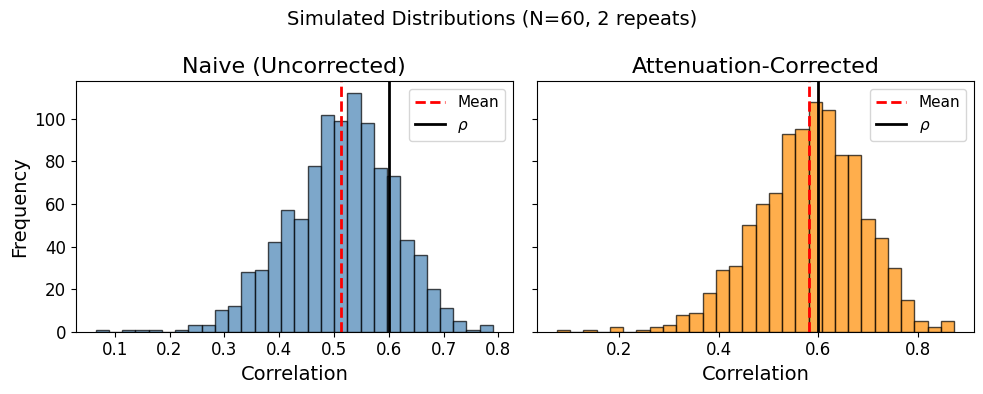

In [ ]:
# Get distributions for visualization
distributions = get_simulation_distributions(
    planned_task1, planned_task2,
    n_subjects=n_subjects,
    n_repeats=n_repeats,
    true_correlation=true_correlation,
    n_iterations=1000,
    random_state=None
)

fig = plot_correlation_histograms(
    distributions['naive'],
    distributions['corrected'],
    true_correlation=true_correlation,
    title=f'Simulated Distributions (N={n_subjects}, {n_repeats} repeats)'
)
plt.show()

In [ ]:
# Run grid search over design parameters
grid_results = run_simulation_grid(
    planned_task1, planned_task2,
    sample_sizes=[15, 30, 60, 120, 240],
    n_repeats_list=[2, 4, 6],
    true_correlation=true_correlation,
    n_iterations=500,
    random_state=None
)

print("\nSimulation Grid Results:")
grid_results.round(3)

Running condition 1/15: N=15, repeats=2
Running condition 2/15: N=15, repeats=4
Running condition 3/15: N=15, repeats=6
Running condition 4/15: N=30, repeats=2
Running condition 5/15: N=30, repeats=4
Running condition 6/15: N=30, repeats=6
Running condition 7/15: N=60, repeats=2
Running condition 8/15: N=60, repeats=4
Running condition 9/15: N=60, repeats=6
Running condition 10/15: N=120, repeats=2
Running condition 11/15: N=120, repeats=4
Running condition 12/15: N=120, repeats=6
Running condition 13/15: N=240, repeats=2
Running condition 14/15: N=240, repeats=4
Running condition 15/15: N=240, repeats=6

Simulation Grid Results:


,n_subjects,n_repeats,true_correlation,naive_mean,naive_sd,naive_rmse,naive_ci_lower,naive_ci_upper,corrected_mean,corrected_sd,corrected_rmse,corrected_ci_lower,corrected_ci_upper,recommended
0,15,2,0.6,0.497,0.211,0.234,-0.001,0.818,0.568,0.239,0.241,-0.001,0.930,Naive (uncorrected)
1,15,4,0.6,0.544,0.189,0.197,0.139,0.827,0.586,0.200,0.201,0.160,0.888,Naive (uncorrected)
2,15,6,0.6,0.572,0.182,0.185,0.130,0.832,0.601,0.190,0.190,0.146,0.865,Naive (uncorrected)
3,30,2,0.6,0.508,0.138,0.166,0.190,0.738,0.575,0.152,0.154,0.212,0.813,Corrected
4,30,4,0.6,0.542,0.140,0.152,0.233,0.774,0.582,0.147,0.148,0.258,0.818,Corrected
5,30,6,0.6,0.564,0.123,0.128,0.288,0.773,0.593,0.127,0.127,0.306,0.806,Corrected
6,60,2,0.6,0.520,0.089,0.120,0.330,0.672,0.589,0.098,0.099,0.378,0.753,Corrected
7,60,4,0.6,0.549,0.086,0.100,0.370,0.705,0.589,0.091,0.091,0.403,0.753,Corrected
8,60,6,0.6,0.573,0.087,0.091,0.394,0.721,0.601,0.090,0.090,0.412,0.755,Corrected
9,120,2,0.6,0.520,0.063,0.102,0.396,0.638,0.588,0.070,0.071,0.449,0.714,Corrected


/Users/annabruns/Documents/~NYU/Research/Crowding/correlation/github/crowding-individual-difference/toolbox-and-tutorial/correlationToolbox/visualization.py:500: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_numeric = pivot.applymap(lambda x: 1 if 'Corrected' in str(x) else 0)


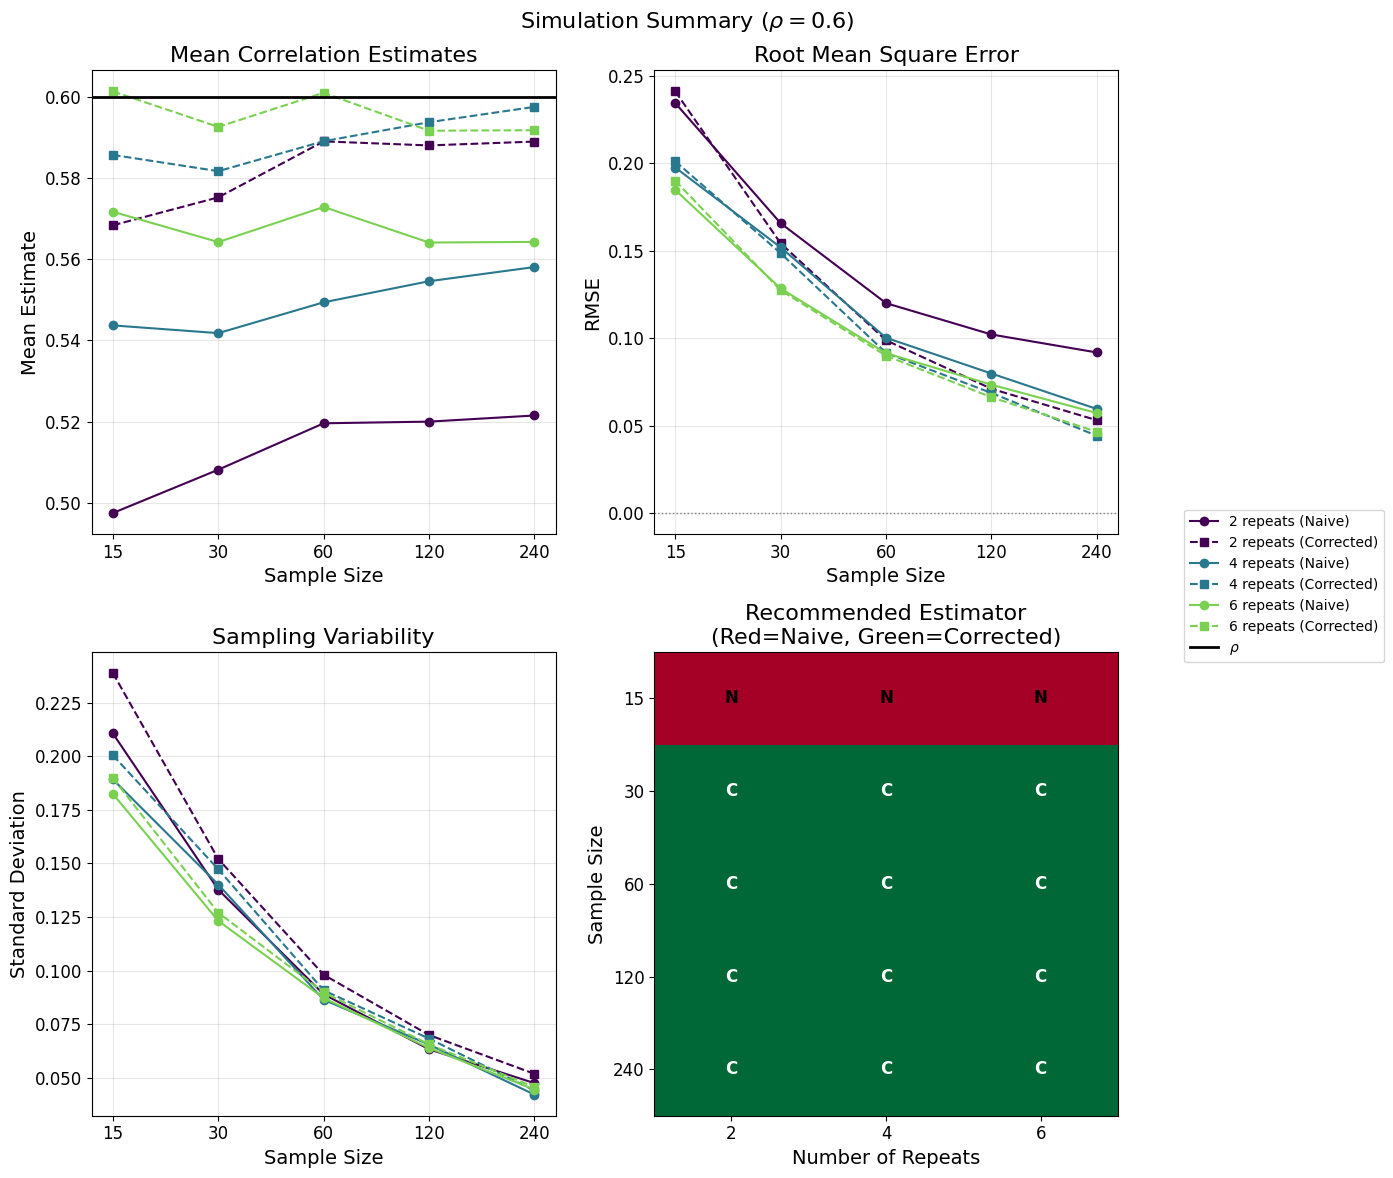

In [12]:
# Comprehensive summary plot
fig = plot_simulation_summary(grid_results, true_correlation=true_correlation)
plt.show()

---

# Summary

## Key Functions

| Function | Use Case |
|----------|----------|
| `analyze_correlation()` | Analyze single pair of tasks |
| `analyze_all_pairs()` | Analyze all pairwise correlations |
| `run_simulation()` | Evaluate estimators for specific design |
| `run_simulation_grid()` | Compare across multiple designs |
| `plot_correlation_heatmaps()` | Visualize naive vs. corrected |
| `plot_simulation_summary()` | Comprehensive simulation results |